# 24 Best Models standalone

## Import

In [5]:
import time

import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import matplotlib as mpl
import matplotlib.pyplot as plt

import seaborn as sns

In [6]:
mpl.style.use("seaborn-v0_8-colorblind")
RANDOM_STATE = 42

## Dataframe

In [7]:
df_raw = fetch_openml(data_id=42742, as_frame=True).frame

In [8]:
feat_cols = [col for col in df_raw.columns if col not in ("target",)]
cat_cols = [col for col in feat_cols if col.endswith("_cat")]
bin_cols = [col for col in feat_cols if col.endswith("_bin")]
num_cols = [col for col in feat_cols if col not in cat_cols and col not in bin_cols]

for col in cat_cols:
    df_raw[col] = df_raw[col].astype("category")

for col in bin_cols:
    if df_raw[col].isna().sum() == 0:
        df_raw[col] = df_raw[col].astype(int).astype("bool")
    else:
        df_raw[col] = df_raw[col].astype("Int8")

for col in num_cols:
    df_raw[col] = df_raw[col].astype("float32")

df_raw["target"] = df_raw["target"].astype(int).astype("bool")

idx_train = np.load("../../../data/processed/train_idx.npy")
idx_val = np.load("../../../data/processed/val_idx.npy")
idx_test = np.load("../../../data/processed/test_idx.npy")

df_train = df_raw.iloc[idx_train]
df_val = df_raw.iloc[idx_val]
df_test = df_raw.iloc[idx_test]

x_train, y_train = df_train[feat_cols], df_train["target"]
x_val, y_val = df_val[feat_cols], df_val["target"]
x_test, y_test = df_test[feat_cols], df_test["target"]

pd.Series(
    {
        "train": [len(df_train), len(x_train), len(y_train)],
        "val": [len(df_val), len(x_val), len(y_val)],
        "test": [len(df_test), len(x_test), len(y_test)]
    }
)

train    [476168, 476168, 476168]
val         [59522, 59522, 59522]
test        [59522, 59522, 59522]
dtype: object

## Hilfsvariablen

In [9]:
results = []
train_times = {}
modelle = {}

In [10]:
calc_cols = [c for c in feat_cols if c.startswith("ps_calc_")]

num_cols_no_calc = [c for c in num_cols if c not in calc_cols]
bin_cols_no_calc = [c for c in bin_cols if c not in calc_cols]
feat_cols_no_calc = [c for c in feat_cols if c not in calc_cols]

high_kard_cols = ["ps_car_11_cat"]
low_kard_cols = [c for c in cat_cols if c not in high_kard_cols]

## Hilfsfunktionen

In [11]:
def eval_modell(mod_idx, model, x_train, y_train, x_val, y_val, x_test, y_test, train_time, best_iter=None):
    """AUC auf Train und Val"""
    auc_train = roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])
    auc_val = roc_auc_score(y_val, model.predict_proba(x_val)[:, 1])
    auc_test = roc_auc_score(y_test, model.predict_proba(x_test)[:, 1])
    return {
        "model_idx": mod_idx,
        "auc_train": auc_train,
        "auc_val": auc_val,
        "auc_test": auc_test,
        "gini_val": 2 * auc_val - 1,
        "gini_test": 2 * auc_test - 1,
        "delta_auc_train_val": auc_train - auc_val,
        "delta_auc_train_test": auc_train - auc_test,
        "delta_auc_val_test": auc_val - auc_test,
        "best_iter": best_iter,
        "trainingszeit": train_time
    }

In [12]:
def mv_for_cb(df, fill_var="missing"):
    """df copy mit ersetzten nans"""
    outs = df.copy()
    for col in outs.columns:
        if outs[col].dtype.name == "category":
            if fill_var not in outs[col].cat.categories:
                outs[col] = outs[col].cat.add_categories([fill_var])
            outs[col] = outs[col].fillna(fill_var)
    return outs

## Modelle

### L_hgb_opt_04

In [13]:
RANDOM_STATE=42

In [14]:
name = "L_hgb_opt_04"

L_hgb_opt_04 = Pipeline([
    ("prep", make_pipeline(
        make_column_transformer(
            (
                TargetEncoder(
                    cv=5,
                    shuffle=True,
                    smooth=50.0,
                    random_state=RANDOM_STATE
                ), cat_cols
            ),
            ("passthrough", num_cols_no_calc + bin_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas"),
        make_column_transformer(
            ("passthrough", feat_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas")
    )),
    ("clf", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        verbose=0,
        loss="log_loss",
        class_weight=None,
        categorical_features=None,
        scoring="loss",
        max_iter=5000,
        early_stopping=True,
        max_leaf_nodes=None,
        learning_rate=0.024687148414834312,
        min_samples_leaf=165,
        l2_regularization=0.004711123505991509,
        max_features=0.2469806711366302,
        max_bins=144,
        interaction_cst=None,
        validation_fraction=0.014823091721617599,
        n_iter_no_change=34,
        tol=8.37065478390795e-08,
        max_depth=6
    ))
])

In [15]:
start = time.time()
L_hgb_opt_04.fit(x_train, y_train)
train_times[name] = time.time() - start

modelle[name] = L_hgb_opt_04

results.append(
    eval_modell(name, L_hgb_opt_04, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_hgb_opt_04["clf"].n_iter_)
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


## L_xgb_opt_02

In [16]:
name = "L_xgb_opt_02"

L_xgb_opt_02 = Pipeline([
    ("prep", make_column_transformer(
        ("passthrough", feat_cols_no_calc),
        remainder="drop",
        verbose_feature_names_out=False
    ).set_output(transform="pandas")),
    ("clf", XGBClassifier(
        random_state=RANDOM_STATE,
        verbosity=0,
        device="cpu",
        n_jobs=-1,
        tree_method="hist",
        objective="binary:logistic",
        eval_metric="auc",
        enable_categorical=True,
        n_estimators=3000,
        early_stopping_rounds=100,
        learning_rate=0.07790268189585514,
        max_depth=7,
        min_child_weight=126.48831841040663,
        gamma=0.49311029649427224,
        reg_lambda=2.2458304124422743,
        reg_alpha=0.055327262047932445,
        max_delta_step=7,
        subsample=0.800054663467233,
        colsample_bynode=0.8968596357800713,
        scale_pos_weight=1,
        max_cat_to_onehot=105
    ))
])

In [17]:
x_val_xgb = L_xgb_opt_02["prep"].fit_transform(x_val)

In [18]:
start = time.time()
L_xgb_opt_02.fit(x_train, y_train, clf__eval_set=[(x_val_xgb, y_val)])
train_times[name] = time.time() - start

modelle[name] = L_xgb_opt_02

results.append(
    eval_modell(name, L_xgb_opt_02, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_xgb_opt_02["clf"].best_iteration)
)

[0]	validation_0-auc:0.60092
[1]	validation_0-auc:0.60441
[2]	validation_0-auc:0.60771
[3]	validation_0-auc:0.61099
[4]	validation_0-auc:0.61163
[5]	validation_0-auc:0.61371
[6]	validation_0-auc:0.61658
[7]	validation_0-auc:0.61757
[8]	validation_0-auc:0.61919
[9]	validation_0-auc:0.62000
[10]	validation_0-auc:0.62109
[11]	validation_0-auc:0.62191
[12]	validation_0-auc:0.62276
[13]	validation_0-auc:0.62309
[14]	validation_0-auc:0.62423
[15]	validation_0-auc:0.62480
[16]	validation_0-auc:0.62536
[17]	validation_0-auc:0.62619
[18]	validation_0-auc:0.62676
[19]	validation_0-auc:0.62711
[20]	validation_0-auc:0.62727
[21]	validation_0-auc:0.62793
[22]	validation_0-auc:0.62767
[23]	validation_0-auc:0.62798
[24]	validation_0-auc:0.62853
[25]	validation_0-auc:0.62895
[26]	validation_0-auc:0.62942
[27]	validation_0-auc:0.63002
[28]	validation_0-auc:0.63027
[29]	validation_0-auc:0.63071
[30]	validation_0-auc:0.63079
[31]	validation_0-auc:0.63106
[32]	validation_0-auc:0.63158
[33]	validation_0-au

### L_cb_test_02_t

In [19]:
name = "L_cb_test_02_t"

L_cb_test_02_t = Pipeline([
    ("prep", make_pipeline(
        make_column_transformer(
            ("passthrough", feat_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas"),
        FunctionTransformer(mv_for_cb, feature_names_out="one-to-one")
    )),
    ("clf", CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        thread_count=-1,
        eval_metric="AUC",
        loss_function="Logloss",
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        border_count=254,
        verbose=0,
        iterations=5000,
        boosting_type="Plain",
        learning_rate=0.17595817710624895,
        depth=4,
        l2_leaf_reg=3.9143184149527266,
        random_strength=0.5015455446392323,
        one_hot_max_size=10,
        leaf_estimation_iterations=2,
        auto_class_weights=None,
        bootstrap_type="Bernoulli",
        subsample=0.7854715288197278
    ))
])

In [20]:
x_val_cb = L_cb_test_02_t["prep"].fit_transform(x_val)

In [21]:
start = time.time()
L_cb_test_02_t.fit(x_train, y_train, clf__eval_set=[(x_val_cb, y_val)])
train_times[name] = time.time() - start

modelle[name] = L_cb_test_02_t

results.append(
    eval_modell(name, L_cb_test_02_t, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_cb_test_02_t["clf"].get_best_iteration())
)

### L_cb_test_02_t_full

In [22]:
name = "L_cb_test_02_t_full"

L_cb_test_02_t_full = Pipeline([
    ("prep", make_pipeline(
        make_column_transformer(
            ("passthrough", feat_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas"),
        FunctionTransformer(mv_for_cb, feature_names_out="one-to-one")
    )),
    ("clf", CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        thread_count=-1,
        eval_metric="AUC",
        loss_function="Logloss",
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        border_count=254,
        verbose=0,
        iterations=5000,
        boosting_type="Plain",
        learning_rate=0.05445057683691509,
        depth=8,
        l2_leaf_reg=7.076480471311773,
        random_strength=0.8387744815011882,
        one_hot_max_size=18,
        leaf_estimation_iterations=5,
        auto_class_weights=None,
        bootstrap_type="Bayesian",
        bagging_temperature=1.8158099900059381
    ))
])

In [23]:
x_val_cb = L_cb_test_02_t_full["prep"].fit_transform(x_val)

In [24]:
start = time.time()
L_cb_test_02_t_full.fit(x_train, y_train, clf__eval_set=[(x_val_cb, y_val)])
train_times[name] = time.time() - start

modelle[name] = L_cb_test_02_t_full

results.append(
    eval_modell(name, L_cb_test_02_t_full, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_cb_test_02_t_full["clf"].get_best_iteration())
)

### L_cb_test_03_t_full

In [25]:
name = "L_cb_test_03_t_full"

L_cb_test_03_t_full = Pipeline([
    ("prep", make_pipeline(
        make_column_transformer(
            ("passthrough", feat_cols_no_calc),
            remainder="drop",
            verbose_feature_names_out=False
        ).set_output(transform="pandas"),
        FunctionTransformer(mv_for_cb, feature_names_out="one-to-one")
    )),
    ("clf", CatBoostClassifier(
        random_seed=RANDOM_STATE,
        task_type="CPU",
        thread_count=-1,
        eval_metric="AUC",
        loss_function="Logloss",
        allow_writing_files=False,
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
        border_count=254,
        verbose=0,
        iterations=5000,
        boosting_type="Ordered",
        learning_rate=0.10624277494598432,
        depth=7,
        l2_leaf_reg=18.039747295507677,
        random_strength=0.005187373722068937,
        one_hot_max_size=105,
        leaf_estimation_iterations=1,
        auto_class_weights=None,
        bootstrap_type="Bernoulli",
        subsample=0.8119454704358904
    ))
])

In [26]:
x_val_cb = L_cb_test_03_t_full["prep"].fit_transform(x_val)

In [27]:
start = time.time()
L_cb_test_03_t_full.fit(x_train, y_train, clf__eval_set=[(x_val_cb, y_val)])
train_times[name] = time.time() - start

modelle[name] = L_cb_test_03_t_full

results.append(
    eval_modell(name, L_cb_test_03_t_full, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_cb_test_03_t_full["clf"].get_best_iteration())
)

### L_lr_opt_03

In [28]:
name = "L_lr_opt_03"

L_lr_opt_03 = Pipeline([
    ("prep", make_column_transformer(
        (
            make_pipeline(
                SimpleImputer(strategy="median", add_indicator=True),
                StandardScaler()
            ), num_cols_no_calc
        ),
        (
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False,
                drop="first"
            ), low_kard_cols
        ),
        (
            make_pipeline(
                TargetEncoder(
                    cv=5,
                    shuffle=True,
                    smooth=50.0,
                    random_state=RANDOM_STATE
                ),
                StandardScaler()
            ), high_kard_cols
        ),
        ("passthrough", bin_cols_no_calc),
        remainder="drop"
    )),
    ("clf", LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=500,
        tol=1e-4,
        fit_intercept=True,
        penalty="elasticnet",
        solver="saga",
        C=0.029135585913319124,
        l1_ratio=0.8,
        class_weight="balanced"
    ))
])

In [29]:
start = time.time()
L_lr_opt_03.fit(x_train, y_train)
train_times[name] = time.time() - start

modelle[name] = L_lr_opt_03

results.append(
    eval_modell(name, L_lr_opt_03, x_train, y_train, x_val, y_val, x_test, y_test, train_times[name], best_iter=L_lr_opt_03["clf"].n_iter_[0])
)

c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\linus\anaconda3\envs\ADA\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  

## Evaluation

In [30]:
df_results = pd.DataFrame(results).sort_values("auc_test", ascending=False)
df_results

,model_idx,auc_train,auc_val,auc_test,gini_val,gini_test,delta_auc_train_val,delta_auc_train_test,delta_auc_val_test,best_iter,trainingszeit
1,L_xgb_opt_02,0.680683,0.639986,0.649495,0.279972,0.298989,0.040697,0.031189,-0.009508,139,13.808860
4,L_cb_test_03_t_full,0.685571,0.635504,0.647561,0.271008,0.295121,0.050067,0.038010,-0.012057,789,122.528593
0,L_hgb_opt_04,0.683650,0.634533,0.647474,0.269067,0.294947,0.049116,0.036176,-0.012940,365,16.158007
3,L_cb_test_02_t_full,0.692775,0.636402,0.647385,0.272804,0.294769,0.056373,0.045390,-0.010983,558,113.669325
2,L_cb_test_02_t,0.664717,0.633687,0.647273,0.267374,0.294546,0.031030,0.017444,-0.013586,518,60.601810
5,L_lr_opt_03,0.635121,0.618241,0.637237,0.236481,0.274475,0.016880,-0.002117,-0.018997,500,312.081296


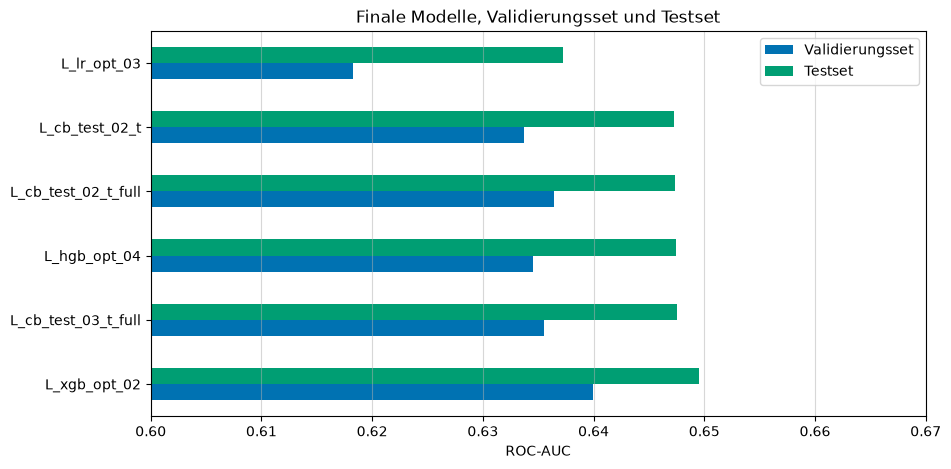

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))

(
    df_results
    .set_index("model_idx")[["auc_val", "auc_test"]]
    .rename(columns={
        "auc_val": "Validierungsset",
        "auc_test": "Testset"
    })
    .plot.barh(
        ax=ax
    )
)

ax.set_xlim(0.60, 0.67)
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("")
ax.set_title("Finale Modelle, Validierungsset und Testset")
ax.legend()
ax.grid(axis="x", alpha=0.5)

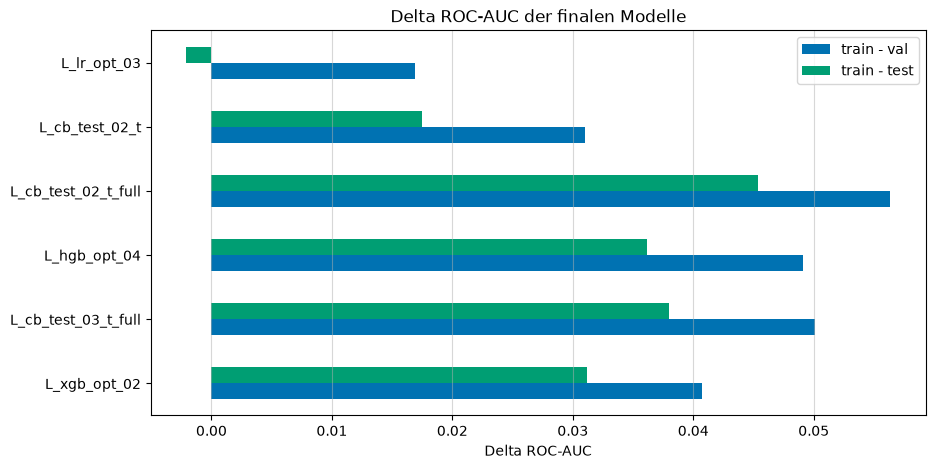

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))

(
    df_results
    .set_index("model_idx")[["delta_auc_train_val", "delta_auc_train_test"]]
    .rename(columns={
        "delta_auc_train_val": "train - val",
        "delta_auc_train_test": "train - test"
    })
    .plot.barh(
        ax=ax
    )
)

ax.set_xlabel("Delta ROC-AUC")
ax.set_ylabel("")
ax.set_title("Delta ROC-AUC der finalen Modelle")
ax.legend()
ax.grid(axis="x", alpha=0.5)

## Ergebnis Überprüfung an Notebook 23

In [33]:
referenz = {
    "L_xgb_opt_02": {"auc_test": 0.649495, "best_iter": 139},
    "L_hgb_opt_04": {"auc_test": 0.647474, "best_iter": 365},
    "L_cb_test_02_t": {"auc_test": 0.647273, "best_iter": 518},
    "L_cb_test_02_t_full": {"auc_test": 0.647385, "best_iter": 558},
    "L_cb_test_03_t_full": {"auc_test": 0.647561, "best_iter": 789},
    "L_lr_opt_03": {"auc_test": 0.637237, "best_iter": 500}
}

In [34]:
check = []

for name, ref in referenz.items():
    row = df_results.loc[df_results["model_idx"] == name].iloc[0]
    check.append({
         "model_idx": name,
        "auc_test_23": ref["auc_test"],
        "auc_test_neu": row["auc_test"],
        "diff_auc": row["auc_test"] - ref["auc_test"],
        "best_iter_23": ref["best_iter"],
        "best_iter_neu": row["best_iter"],
        "identisch": abs(row["auc_test"] - ref["auc_test"]) < 1e-4 and row["best_iter"] == ref["best_iter"]
    })

pd.DataFrame(check)

,model_idx,auc_test_23,auc_test_neu,diff_auc,best_iter_23,best_iter_neu,identisch
0,L_xgb_opt_02,0.649495,0.649495,-4.720969e-07,139,139,True
1,L_hgb_opt_04,0.647474,0.647474,-4.585453e-07,365,365,True
2,L_cb_test_02_t,0.647273,0.647273,1.855940e-07,518,518,True
3,L_cb_test_02_t_full,0.647385,0.647385,-4.064509e-07,558,558,True
4,L_cb_test_03_t_full,0.647561,0.647561,-2.630702e-07,789,789,True
5,L_lr_opt_03,0.637237,0.637237,4.502403e-07,500,500,True


## Predictions

In [35]:
Pred_L_xgb_opt_02 = L_xgb_opt_02.predict_proba(x_test)[:, 1]
Pred_L_hgb_opt_04 = L_hgb_opt_04.predict_proba(x_test)[:, 1]
Pred_L_cb_test_02_t = L_cb_test_02_t.predict_proba(x_test)[:, 1]
Pred_L_cb_test_02_t_full = L_cb_test_02_t_full.predict_proba(x_test)[:, 1]
Pred_L_cb_test_03_t_full = L_cb_test_03_t_full.predict_proba(x_test)[:, 1]
Pred_L_lr_opt_03 = L_lr_opt_03.predict_proba(x_test)[:, 1]

preds_test = pd.DataFrame({
    "Pred_L_xgb_opt_02": L_xgb_opt_02.predict_proba(x_test)[:, 1],
    "Pred_L_hgb_opt_04": L_hgb_opt_04.predict_proba(x_test)[:, 1],
    "Pred_L_cb_test_02_t": L_cb_test_02_t.predict_proba(x_test)[:, 1],
    "Pred_L_cb_test_02_t_full": L_cb_test_02_t_full.predict_proba(x_test)[:, 1],
    "Pred_L_cb_test_03_t_full": L_cb_test_03_t_full.predict_proba(x_test)[:, 1],
    "Pred_L_lr_opt_03": L_lr_opt_03.predict_proba(x_test)[:, 1]
}, index=x_test.index)

## Modelle Korrelation

In [36]:
pred_korr = preds_test.corr(method="spearman").round(3)
pred_korr

,Pred_L_xgb_opt_02,Pred_L_hgb_opt_04,Pred_L_cb_test_02_t,Pred_L_cb_test_02_t_full,Pred_L_cb_test_03_t_full,Pred_L_lr_opt_03
Pred_L_xgb_opt_02,1.000,0.958,0.945,0.951,0.943,0.877
Pred_L_hgb_opt_04,0.958,1.000,0.952,0.958,0.948,0.898
Pred_L_cb_test_02_t,0.945,0.952,1.000,0.965,0.958,0.897
Pred_L_cb_test_02_t_full,0.951,0.958,0.965,1.000,0.956,0.911
Pred_L_cb_test_03_t_full,0.943,0.948,0.958,0.956,1.000,0.884
Pred_L_lr_opt_03,0.877,0.898,0.897,0.911,0.884,1.000


Text(0.5, 1.0, 'Korrelationen der Predictions (Testset)')

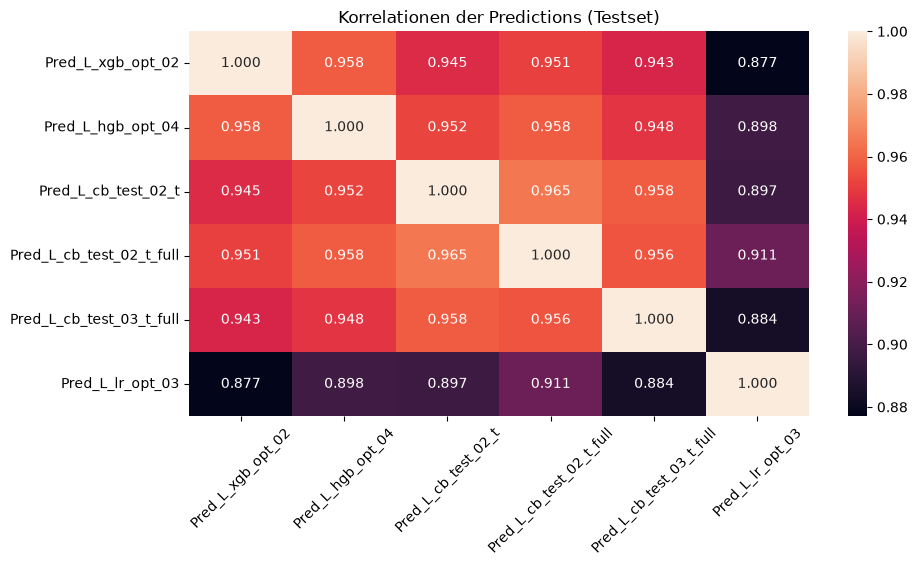

In [37]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(
    pred_korr,
    ax=ax,
    annot=True,
    fmt=".3f"
)
ax.tick_params(axis="x", rotation=45)
ax.set_title("Korrelationen der Predictions (Testset)")

## Ensemble-Methoden-Versuche auf den Bestmodellen (21. & 22.08.26)

In [38]:
# Um die Modelle nicht auf dem Testdatensatz zu optimieren, werden sie anhand ihrer Validierungsleistung gewählt
preds_val = pd.DataFrame({
    "Pred_L_xgb_opt_02": L_xgb_opt_02.predict_proba(x_val)[:, 1],
    "Pred_L_hgb_opt_04": L_hgb_opt_04.predict_proba(x_val)[:, 1],
    "Pred_L_cb_test_02_t": L_cb_test_02_t.predict_proba(x_val)[:, 1],
    "Pred_L_cb_test_02_t_full": L_cb_test_02_t_full.predict_proba(x_val)[:, 1],
    "Pred_L_cb_test_03_t_full": L_cb_test_03_t_full.predict_proba(x_val)[:, 1],
    "Pred_L_lr_opt_03": L_lr_opt_03.predict_proba(x_val)[:, 1]
}, index=x_val.index)

### Experiment 1: Verfahren bei der Ensemble-Abstimmung testen

Verglichen werden a) die simple Bildung eines Durchschnitts der Vorhersagen (Soft Voting), b) die Bildung eines Rang-Durchschnitts, bei dem die Vorhersagen der Einzelmodelle von niedrig nach oben sortiert werden und dann auf dem jeweiligen relativen Rang gemittelt werden, sowie c) die Bildung eines gewichteten Rang-Durchschnitts, bei dem die die Einschätzung der Vorhersagekraft anhand der Einzelmodellgüte durch Stimm-Gewichtung berücksichtigt wird.

In [39]:
ranks_val = preds_val.rank(pct=True)
ranks_test = preds_test.rank(pct=True)

In [40]:
# hier werden für jede Ensemblegröße k die Einzelmodelle neu zusammengestellt
# für die größtmögliche Ensembleleistung. In Experiment 2 schaue ich mir noch
# Alternativen dazu an. D.h. für alle k werden hier alle möglichen Einzel-
# Modellkombis angeschaut

from itertools import combinations

ensemble_results = []

# AUC der einzelnen Modelle als Gewichte
model_auc = {
    model: roc_auc_score(y_val, preds_val[model])
    for model in preds_val.columns
}

for k in range(2, len(preds_val.columns) + 1):

    for modelle_k in combinations(preds_val.columns, k):

        modelle_k = list(modelle_k)


        # Durchschnitt
        pred_val = preds_val[modelle_k].mean(axis=1)
        pred_test = preds_test[modelle_k].mean(axis=1)

        ensemble_results.append({
            "k": k,
            "verfahren": "Durchschnitt",
            "modelle": " + ".join(modelle_k),
            "auc_val": roc_auc_score(y_val, pred_val),
            "auc_test": roc_auc_score(y_test, pred_test)
        })


        # Rang
        pred_val = ranks_val[modelle_k].mean(axis=1)
        pred_test = ranks_test[modelle_k].mean(axis=1)

        ensemble_results.append({
            "k": k,
            "verfahren": "Rang",
            "modelle": " + ".join(modelle_k),
            "auc_val": roc_auc_score(y_val, pred_val),
            "auc_test": roc_auc_score(y_test, pred_test)
        })


        # Gewichteter Rang
        # nach einem ersten Versuch nur mit der ROC-AUC, welche recht ähnlich
        # ist für die unterschiedlichen Einzel-Modelle habe ich die ROC-AUC-
        # Leistung oberhalb von 0.5 (Zufallsniveau) genommen, um Unterschiede
        # etwas hervorzuheben (ähnlich wie normalisierter Gini)
        gewichte = np.array([
            model_auc[model] - 0.5
            for model in modelle_k
        ])

        gewichte = gewichte / gewichte.sum()

        pred_val = (
            ranks_val[modelle_k] * gewichte
        ).sum(axis=1)

        pred_test = (
            ranks_test[modelle_k] * gewichte
        ).sum(axis=1)

        ensemble_results.append({
            "k": k,
            "verfahren": "Gewichteter Rang",
            "modelle": " + ".join(modelle_k),
            "auc_val": roc_auc_score(y_val, pred_val),
            "auc_test": roc_auc_score(y_test, pred_test)
        })

In [41]:
df_ensemble = pd.DataFrame(ensemble_results)

df_ensemble.sort_values(
    "auc_val",
    ascending=False
).head(10)

,k,verfahren,modelle,auc_val,auc_test
8,2,Gewichteter Rang,Pred_L_xgb_opt_02 + Pred_L_cb_test_02_t_full,0.639711,0.649993
7,2,Rang,Pred_L_xgb_opt_02 + Pred_L_cb_test_02_t_full,0.639690,0.649980
6,2,Durchschnitt,Pred_L_xgb_opt_02 + Pred_L_cb_test_02_t_full,0.639550,0.649968
11,2,Gewichteter Rang,Pred_L_xgb_opt_02 + Pred_L_cb_test_03_t_full,0.639513,0.650384
10,2,Rang,Pred_L_xgb_opt_02 + Pred_L_cb_test_03_t_full,0.639479,0.650373
68,3,Gewichteter Rang,Pred_L_xgb_opt_02 + Pred_L_cb_test_02_t_full +...,0.639382,0.650323
67,3,Rang,Pred_L_xgb_opt_02 + Pred_L_cb_test_02_t_full +...,0.639353,0.650307
9,2,Durchschnitt,Pred_L_xgb_opt_02 + Pred_L_cb_test_03_t_full,0.639274,0.650179
66,3,Durchschnitt,Pred_L_xgb_opt_02 + Pred_L_cb_test_02_t_full +...,0.639191,0.650251
116,4,Gewichteter Rang,Pred_L_xgb_opt_02 + Pred_L_hgb_opt_04 + Pred_L...,0.638808,0.650308


In [42]:
best_pro_k = (
    df_ensemble
    .sort_values("auc_val", ascending=False)
    .groupby(["verfahren", "k"])
    .head(1)
    .sort_values(["verfahren", "k"])
)

best_pro_k[
    [
        "k",
        "verfahren",
        "modelle",
        "auc_val",
        "auc_test"
    ]
].to_csv("best_pro_k.csv")

best_pro_k[
    [
        "k",
        "verfahren",
        "modelle",
        "auc_val",
        "auc_test"
    ]
]

,k,verfahren,modelle,auc_val,auc_test
6,2,Durchschnitt,Pred_L_xgb_opt_02 + Pred_L_cb_test_02_t_full,0.639550,0.649968
66,3,Durchschnitt,Pred_L_xgb_opt_02 + Pred_L_cb_test_02_t_full +...,0.639191,0.650251
114,4,Durchschnitt,Pred_L_xgb_opt_02 + Pred_L_hgb_opt_04 + Pred_L...,0.638656,0.650260
150,5,Durchschnitt,Pred_L_xgb_opt_02 + Pred_L_hgb_opt_04 + Pred_L...,0.638187,0.650164
168,6,Durchschnitt,Pred_L_xgb_opt_02 + Pred_L_hgb_opt_04 + Pred_L...,0.629604,0.645572
8,2,Gewichteter Rang,Pred_L_xgb_opt_02 + Pred_L_cb_test_02_t_full,0.639711,0.649993
68,3,Gewichteter Rang,Pred_L_xgb_opt_02 + Pred_L_cb_test_02_t_full +...,0.639382,0.650323
116,4,Gewichteter Rang,Pred_L_xgb_opt_02 + Pred_L_hgb_opt_04 + Pred_L...,0.638808,0.650308
152,5,Gewichteter Rang,Pred_L_xgb_opt_02 + Pred_L_hgb_opt_04 + Pred_L...,0.638324,0.650236
170,6,Gewichteter Rang,Pred_L_xgb_opt_02 + Pred_L_hgb_opt_04 + Pred_L...,0.636702,0.649776


In [43]:
# Namen für die Grafik
kurz = {
    "Pred_L_xgb_opt_02": "XGB",
    "Pred_L_hgb_opt_04": "HGB",
    "Pred_L_cb_test_02_t": "Cat1",
    "Pred_L_cb_test_02_t_full": "Cat2",
    "Pred_L_cb_test_03_t_full": "Cat3",
    "Pred_L_lr_opt_03": "LogReg"
}

best_pro_k = best_pro_k.copy()

best_pro_k["modelle_kurz"] = best_pro_k["modelle"]

best_pro_k["modelle_kurz"] = best_pro_k["modelle"].apply(
    lambda x: " + ".join(
        kurz.get(modell, modell)
        for modell in x.split(" + ")
    )
)

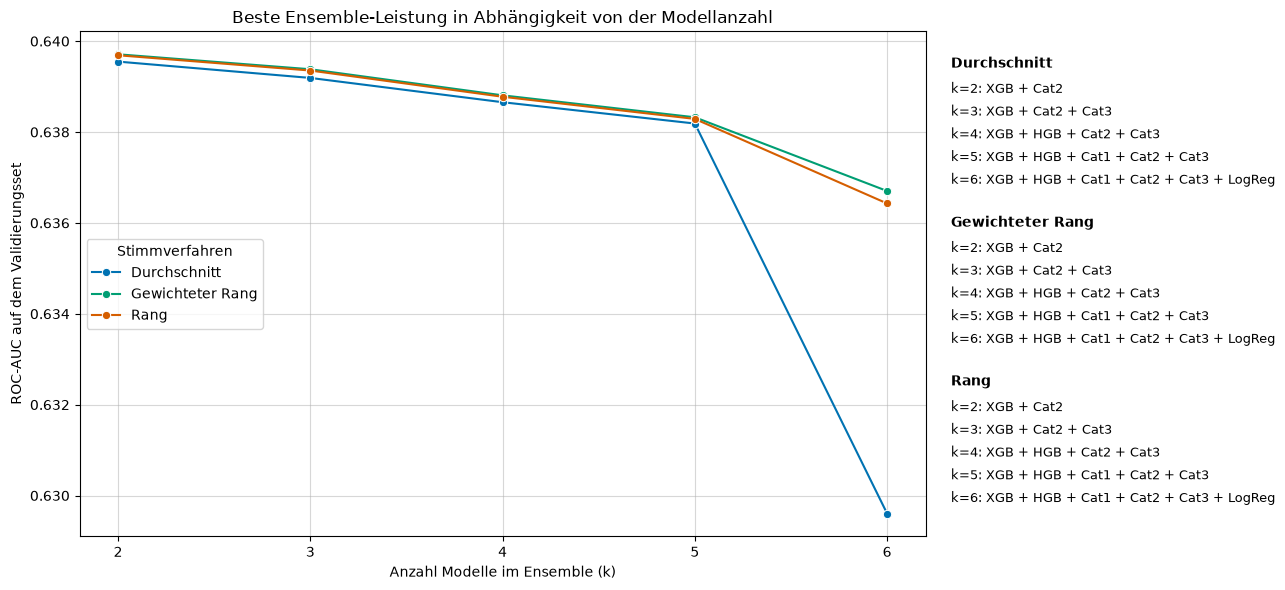

In [44]:
fig, ax = plt.subplots(figsize=(13, 6))

sns.lineplot(
    data=best_pro_k,
    x="k",
    y="auc_val",
    hue="verfahren",
    marker="o",
    ax=ax
)

ax.set_xlabel("Anzahl Modelle im Ensemble (k)")
ax.set_ylabel("ROC-AUC auf dem Validierungsset")
ax.set_title("Beste Ensemble-Leistung in Abhängigkeit von der Modellanzahl")

ax.set_xticks(range(2, 7))

ax.legend(
    title="Stimmverfahren",
    loc="center left"
)

ax.grid(alpha=0.5)


# Kombinationen rechts daneben anzeigen
text_y = 0.95

for verfahren in best_pro_k["verfahren"].unique():

    ax.text(
        1.03,
        text_y,
        verfahren,
        transform=ax.transAxes,
        fontweight="bold",
        va="top"
    )

    text_y -= 0.05

    temp = (
        best_pro_k[
            best_pro_k["verfahren"] == verfahren
        ]
        .sort_values("k")
    )

    for _, row in temp.iterrows():

        ax.text(
            1.03,
            text_y,
            f'k={row["k"]}: {row["modelle_kurz"]}',
            transform=ax.transAxes,
            va="top",
            fontsize=9
        )

        text_y -= 0.045

    text_y -= 0.04

plt
plt.tight_layout()
plt.show()

### Experiment 2: Verfahren bei der Modellbildung testen

Es gibt verschiedene Wege zu entscheiden, wie man zu einem Ensembles (weitere) Einzelmodelle hinzufügt. Hier werden drei Verfahren verglichen: a) die zufällige Hinzunahme eines weiteren Modells ohne weitere Heuristik, b) Greedy Selection als Mechanismus, bei dem zuerst das beste Einzelmodelle gewählt wird und darauf basierend schrittweise dasjenige Modell hinzugefügt wird, was den höchsten Leistungs-Zugewinn bringt, sowie c) die Top-Leistungs-Selektion, bei der alle Kombinationen miteinander getestet werden, um für jede Ensemblegröße k unabhängig die beste Zusammenstellung zu finden. Da im vorherigen Experiment der gewichtete Rang für die Abstimmung das minimal bessere Ergebnis hatte als Rang, wird dieser Abstimmungs-Mechanismus verwendet.

In [45]:
def ensemble_pred(modelle, ranks):

    gewichte = np.array([
        model_auc[m] - 0.5
        for m in modelle
    ])

    gewichte = gewichte / gewichte.sum()

    return (ranks[modelle] * gewichte).sum(axis=1)

In [46]:
pred_val = ensemble_pred(
    modelle_k,
    ranks_val
)

In [47]:
# Auswahl der Ensembles nach absoluter Performance
absolute = (
    df_ensemble[
        df_ensemble["verfahren"] == "Gewichteter Rang"
    ]
    .sort_values("auc_val", ascending=False)
    .groupby("k")
    .head(1)
    .sort_values("k")
    .copy()
)

absolute["auswahl"] = "Absolute Performance"

In [48]:
# zufällige Auswahl der Modelle nacheinander als Baseline
bestes_einzelmodell = max(
    model_auc,
    key=model_auc.get
)

rng = np.random.default_rng(RANDOM_STATE)

rest = [
    m for m in preds_val.columns
    if m != bestes_einzelmodell
]

reihenfolge = [
    bestes_einzelmodell,
    *rng.permutation(rest)
]

In [49]:
random_results = []

for k in range(2, 7):

    modelle_k = list(reihenfolge[:k])

    pred_val = ensemble_pred(
        modelle_k,
        ranks_val
    )

    pred_test = ensemble_pred(
        modelle_k,
        ranks_test
    )

    random_results.append({
        "k": k,
        "auswahl": "Zufällig",
        "modelle": " + ".join(modelle_k),
        "auc_val": roc_auc_score(y_val, pred_val),
        "auc_test": roc_auc_score(y_test, pred_test)
    })

random_results = pd.DataFrame(random_results)

In [50]:
# Greedy Selection: Erst wird das beste Modelle gewählt, danach
# wird dasjenige mit dem höchsten Ensemblegain mit dem Ersten gezogen usw.
greedy_results = []

ausgewaehlt = [bestes_einzelmodell]

for k in range(2, 7):

    best_auc = 0
    best_model = None

    for model in preds_val.columns:

        if model in ausgewaehlt:
            continue

        kandidaten = ausgewaehlt + [model]

        pred_val = ensemble_pred(
            kandidaten,
            ranks_val
        )

        auc = roc_auc_score(
            y_val,
            pred_val
        )

        if auc > best_auc:
            best_auc = auc
            best_model = model

    ausgewaehlt.append(best_model)

    pred_test = ensemble_pred(
        ausgewaehlt,
        ranks_test
    )

    greedy_results.append({
        "k": k,
        "auswahl": "Greedy",
        "modelle": " + ".join(ausgewaehlt),
        "auc_val": best_auc,
        "auc_test": roc_auc_score(y_test, pred_test)
    })

greedy_results = pd.DataFrame(greedy_results)

In [51]:
absolute_simple = absolute[
    ["k", "auswahl", "modelle", "auc_val", "auc_test"]
]

df_auswahl = pd.concat([
    absolute_simple,
    random_results,
    greedy_results
])

df_auswahl = df_auswahl.sort_values([
    "auswahl",
    "k"
])

df_auswahl

,k,auswahl,modelle,auc_val,auc_test
8,2,Absolute Performance,Pred_L_xgb_opt_02 + Pred_L_cb_test_02_t_full,0.639711,0.649993
68,3,Absolute Performance,Pred_L_xgb_opt_02 + Pred_L_cb_test_02_t_full +...,0.639382,0.650323
116,4,Absolute Performance,Pred_L_xgb_opt_02 + Pred_L_hgb_opt_04 + Pred_L...,0.638808,0.650308
152,5,Absolute Performance,Pred_L_xgb_opt_02 + Pred_L_hgb_opt_04 + Pred_L...,0.638324,0.650236
170,6,Absolute Performance,Pred_L_xgb_opt_02 + Pred_L_hgb_opt_04 + Pred_L...,0.636702,0.649776
0,2,Greedy,Pred_L_xgb_opt_02 + Pred_L_cb_test_02_t_full,0.639711,0.649993
1,3,Greedy,Pred_L_xgb_opt_02 + Pred_L_cb_test_02_t_full +...,0.639382,0.650323
2,4,Greedy,Pred_L_xgb_opt_02 + Pred_L_cb_test_02_t_full +...,0.638808,0.650308
3,5,Greedy,Pred_L_xgb_opt_02 + Pred_L_cb_test_02_t_full +...,0.638324,0.650236
4,6,Greedy,Pred_L_xgb_opt_02 + Pred_L_cb_test_02_t_full +...,0.636702,0.649776


In [52]:
df_auswahl["modelle_kurz"] = df_auswahl["modelle"].apply(
    lambda x: " + ".join(
        kurz.get(modell, modell)
        for modell in x.split(" + ")
    )
)

NameError: name 'best_verfahren' is not defined

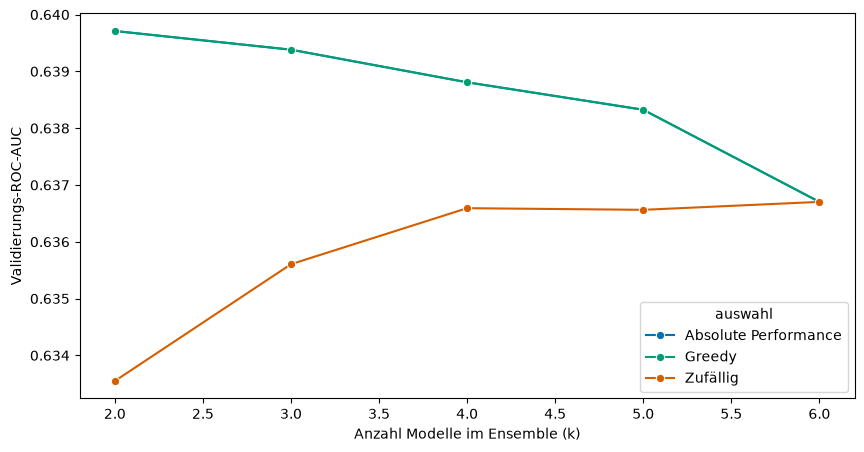

In [53]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=df_auswahl,
    x="k",
    y="auc_val",
    hue="auswahl",
    marker="o",
    ax=ax
)

ax.set_xlabel("Anzahl Modelle im Ensemble (k)")
ax.set_ylabel("Validierungs-ROC-AUC")

ax.set_title(
    f"Vergleich der Modellauswahl ({best_verfahren})"
)

ax.set_xticks(range(2, 7))

ax.legend(
    title="Auswahlverfahren"
)

ax.grid(alpha=0.5)

plt.savefig("ensemble_selection.pdf", format="pdf", bbox_inches="tight")

plt.show()

### Experiment 3: Seed-Ensembles auf den stärksten Einzelmodellen

Um zu testen ob sich der Zugewinn an Leistung durch die Ensemble-Bildung nur durch die unterschiedlichen Modell-Verfahren zustande kommt, oder die Robustheit der Leistung von starken Einzel-Modelle nicht selbst durch Variation z.B. des Seeds erhöhen lassen kann, soll im nächsten Schritt durch das Training und Kombination der stärksten Einzelmodelle (CatBoost, XGBoost, HistGradientBoosting und logistischer Regression) auf verschiedenen Seeds überprüft werden.

In [ ]:
from itertools import combinations

In [ ]:
from sklearn.base import clone

seeds = [42, 123, 456, 789, 2026, 12, 56, 214, 90, 30, 1709, 851, 970, 1205, 16]

best_modelle = {
    "XGBoost": L_xgb_opt_02,
    "HGB": L_hgb_opt_04,
    "CatBoost": L_cb_test_02_t_full,
    "LogReg": L_lr_opt_03
}

In [ ]:
seed_basen = {
    "XGBoost": clone(L_xgb_opt_02),
    "HGB": clone(L_hgb_opt_04),
    "LogReg": clone(L_lr_opt_03)
}

In [ ]:
# bei CatBoost hat es nicht funktioniert, vllt. da der trainierte Zustand
# mit kopiert wurde und man diesen nicht mehr ändern kann danach,
# deswegen wird dafür aber eine neue Kopie erzeugt
cat_params = L_cb_test_02_t_full["clf"].get_params()

seed_basen["CatBoost"] = Pipeline([
    ("prep", clone(L_cb_test_02_t_full["prep"])),
    ("clf", CatBoostClassifier(**cat_params))
])

In [ ]:
seed_basen["XGBoost"].set_params(
    clf__n_estimators=L_xgb_opt_02["clf"].best_iteration + 1,
    clf__early_stopping_rounds=None
)

seed_basen["HGB"].set_params(
    clf__max_iter=L_hgb_opt_04["clf"].n_iter_,
    clf__early_stopping=False
)

seed_basen["CatBoost"].set_params(
    clf__iterations=L_cb_test_02_t_full["clf"].get_best_iteration() + 1,
    clf__use_best_model=False,
    clf__early_stopping_rounds=None
)

Pipeline(steps=[('prep',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(transformers=[('passthrough',
                                                                   'passthrough',
                                                                   ['ps_ind_01',
                                                                    'ps_ind_02_cat',
                                                                    'ps_ind_03',
                                                                    'ps_ind_04_cat',
                                                                    'ps_ind_05_cat',
                                                                    'ps_ind_06_bin',
                                                                    'ps_ind_07_bin',
                                                                    'ps_ind_08_bin',
                                                                    'ps_ind_09_bin',
                                                                    'ps_ind_10_bin',
                                                                    'ps_ind_11_bin',
                                                                    'ps_ind_12_bin',
                                                                    'ps_ind_13_bin',
                                                                    'ps_ind_14',
                                                                    'ps_ind_15',
                                                                    'ps...
                 CatBoostClassifier(allow_writing_files=False, bagging_temperature=1.8158099900059381, boosting_type='Plain', bootstrap_type='Bayesian', border_count=254, cat_features=['ps_ind_02_cat', 'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_car_01_cat', 'ps_car_02_cat', 'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat', 'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat', 'ps_car_11_cat'], depth=8, early_stopping_rounds=None, eval_metric='AUC', iterations=559, l2_leaf_reg=7.076480471311773, leaf_estimation_iterations=5, learning_rate=0.05445057683691509, loss_function='Logloss', one_hot_max_size=18, random_seed=42, random_strength=0.8387744815011882, task_type='CPU', use_best_model=False, verbose=0))])

In [ ]:
def set_seed(model, seed):

    model = copy.deepcopy(model)

    params = {}

    for param in model.get_params():

        if param.endswith("random_state"):
            params[param] = seed

        if param.endswith("random_seed"):
            params[param] = seed

    model.set_params(**params)

    return model

In [ ]:
# Modelle trainieren
import copy

seed_preds_val = {}
seed_preds_test = {}

for name, basis in seed_basen.items():

    seed_preds_val[name] = pd.DataFrame(index=x_val.index)
    seed_preds_test[name] = pd.DataFrame(index=x_test.index)

    for seed in seeds:

        print(name, seed)

        model = set_seed(basis, seed)

        model.fit(
            x_train,
            y_train
        )

        seed_preds_val[name][f"Seed {seed}"] = (
            model.predict_proba(x_val)[:, 1]
        )

        seed_preds_test[name][f"Seed {seed}"] = (
            model.predict_proba(x_test)[:, 1]
        )

XGBoost 42
XGBoost 123
XGBoost 456
XGBoost 789
XGBoost 2026
XGBoost 12
XGBoost 56
XGBoost 214
XGBoost 90
XGBoost 30
XGBoost 1709
XGBoost 851
XGBoost 970
XGBoost 1205
XGBoost 16
HGB 42
HGB 123
HGB 456
HGB 789
HGB 2026
HGB 12
HGB 56
HGB 214
HGB 90
HGB 30
HGB 1709
HGB 851
HGB 970
HGB 1205
HGB 16
LogReg 42


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogReg 123


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogReg 456


...

LogReg 1205


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogReg 16


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


CatBoost 42
CatBoost 123
CatBoost 456
CatBoost 789
CatBoost 2026
CatBoost 12
CatBoost 56
CatBoost 214
CatBoost 90
CatBoost 30
CatBoost 1709
CatBoost 851
CatBoost 970
CatBoost 1205
CatBoost 16


In [ ]:
seed_ranks_val = {}
seed_ranks_test = {}
seed_auc = {}

for name in best_modelle:

    seed_ranks_val[name] = (
        seed_preds_val[name].rank(pct=True)
    )

    seed_ranks_test[name] = (
        seed_preds_test[name].rank(pct=True)
    )

    seed_auc[name] = {
        col: roc_auc_score(
            y_val,
            seed_preds_val[name][col]
        )
        for col in seed_preds_val[name]
    }

In [ ]:
seed_daten = {
    "val": seed_preds_val,
    "test": seed_preds_test
}

pd.to_pickle(
    seed_daten,
    "seed_predictions_15.pkl"
)

In [ ]:
seed_results = []

for name in best_modelle:

    for k in range(1, len(seeds) + 1):

        best_auc = 0
        best_combo = None

        for combo in combinations(
            seed_preds_val[name].columns,
            k
        ):

            combo = list(combo)

            gewichte = np.array([
                seed_auc[name][seed] - 0.5
                for seed in combo
            ])

            gewichte = gewichte / gewichte.sum()

            pred_val = (
                seed_ranks_val[name][combo]
                * gewichte
            ).sum(axis=1)

            auc = roc_auc_score(
                y_val,
                pred_val
            )

            if auc > best_auc:
                best_auc = auc
                best_combo = combo


        # Test erst für beste Kombination dieses k
        gewichte = np.array([
            seed_auc[name][seed] - 0.5
            for seed in best_combo
        ])

        gewichte = gewichte / gewichte.sum()

        pred_test = (
            seed_ranks_test[name][best_combo]
            * gewichte
        ).sum(axis=1)

        seed_results.append({
            "modell": name,
            "k": k,
            "seeds": " + ".join(best_combo),
            "auc_val": best_auc,
            "auc_test": roc_auc_score(
                y_test,
                pred_test
            )
        })

In [ ]:
df_seed = pd.DataFrame(seed_results)

df_seed.sort_values([
    "modell",
    "k"
]).to_csv("seed_ensemble_overview_results.csv")

df_seed.sort_values([
    "modell",
    "k"
])


,modell,k,seeds,auc_val,auc_test
30,CatBoost,1,Seed 42,0.636402,0.647385
31,CatBoost,2,Seed 42 + Seed 970,0.636963,0.648475
32,CatBoost,3,Seed 42 + Seed 851 + Seed 970,0.637105,0.648398
33,CatBoost,4,Seed 42 + Seed 56 + Seed 851 + Seed 970,0.637125,0.648989
34,CatBoost,5,Seed 42 + Seed 456 + Seed 56 + Seed 851 + Seed...,0.637009,0.648969
35,CatBoost,6,Seed 42 + Seed 456 + Seed 56 + Seed 90 + Seed ...,0.636901,0.648827
36,CatBoost,7,Seed 42 + Seed 456 + Seed 56 + Seed 90 + Seed ...,0.636779,0.648909
37,CatBoost,8,Seed 42 + Seed 456 + Seed 12 + Seed 56 + Seed ...,0.636662,0.648968
38,CatBoost,9,Seed 42 + Seed 456 + Seed 789 + Seed 12 + Seed...,0.636545,0.649086
39,CatBoost,10,Seed 42 + Seed 456 + Seed 789 + Seed 12 + Seed...,0.636427,0.649258


In [ ]:
len(df_seed)

60

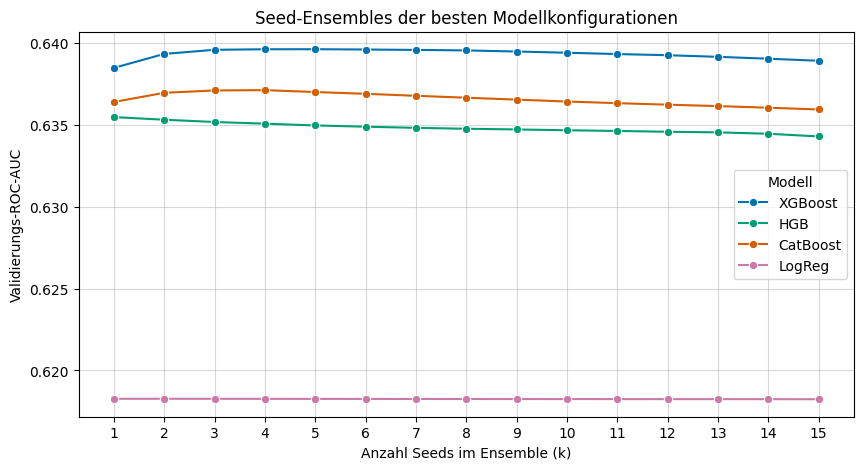

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=df_seed,
    x="k",
    y="auc_val",
    hue="modell",
    marker="o",
    ax=ax
)

ax.set_xlabel("Anzahl Seeds im Ensemble (k)")
ax.set_ylabel("Validierungs-ROC-AUC")

ax.set_title(
    "Seed-Ensembles der besten Modellkonfigurationen"
)

ax.set_xticks(range(1, 16))

ax.legend(
    title="Modell"
)

ax.grid(alpha=0.5)
plt.savefig("seed_ensemble.pdf", format="pdf", bbox_inches="tight")

plt.show()

### Experiment 4: Stacking-Ensembles auf den stärksten Einzelmodellen

Stacking ist eine klassische Ensemble-Strategie, bei der ein Metalerner verwendet wird, der mit den Einzelmodellen und ihren Vorhersagen als neue Features lernt, daraus eine finale Vorhersage zu formen. Die Hoffnung beim Einsatz von Stacking ist, dass ein Modell dynamisch lernen kann, welchem Ensemble-Mitglied wann zu vertrauen ist anstatt z.B. nur einen starren Durchschnitt über alle Vorhersagen zu ziehen.

In [ ]:
stacking_modelle = {
    "XGBoost": L_xgb_opt_02,
    "HGB": L_hgb_opt_04,
    "Cat1": L_cb_test_02_t,
    "Cat2": L_cb_test_02_t_full,
    "Cat3": L_cb_test_03_t_full,
    "LogReg": L_lr_opt_03
}

In [ ]:
stack_basen = {
    "XGBoost": clone(L_xgb_opt_02),
    "HGB": clone(L_hgb_opt_04),
    "LogReg": clone(L_lr_opt_03)
}

In [ ]:
# Da oben auf Catboost kein clone() funktioniert hatte
for name, model in {
    "Cat1": L_cb_test_02_t,
    "Cat2": L_cb_test_02_t_full,
    "Cat3": L_cb_test_03_t_full
}.items():

    params = model["clf"].get_params()

    stack_basen[name] = Pipeline([
        ("prep", clone(model["prep"])),
        ("clf", CatBoostClassifier(**params))
    ])

In [ ]:
stack_basen["XGBoost"].set_params(
    clf__n_estimators=L_xgb_opt_02["clf"].best_iteration + 1,
    clf__early_stopping_rounds=None
)

stack_basen["HGB"].set_params(
    clf__max_iter=L_hgb_opt_04["clf"].n_iter_,
    clf__early_stopping=False
)

Pipeline(steps=[('prep',
                 Pipeline(steps=[('columntransformer-1',
                                  ColumnTransformer(transformers=[('targetencoder',
                                                                   TargetEncoder(random_state=42,
                                                                                 smooth=50.0),
                                                                   ['ps_ind_02_cat',
                                                                    'ps_ind_04_cat',
                                                                    'ps_ind_05_cat',
                                                                    'ps_car_01_cat',
                                                                    'ps_car_02_cat',
                                                                    'ps_car_03_cat',
                                                                    'ps_car_04_cat',
                                                                    'ps_car_05_cat',
                                                                    'ps_car_06_cat',
                                                                    'ps_car_07_cat',
                                                                    'ps_car_08_cat',
                                                                    'ps_car_09_cat',
                                                                    'p...
                 HistGradientBoostingClassifier(categorical_features=None,
                                                early_stopping=False,
                                                l2_regularization=0.004711123505991509,
                                                learning_rate=0.024687148414834312,
                                                max_bins=144, max_depth=6,
                                                max_features=0.2469806711366302,
                                                max_iter=282,
                                                max_leaf_nodes=None,
                                                min_samples_leaf=165,
                                                n_iter_no_change=34,
                                                random_state=42,
                                                tol=8.37065478390795e-08,
                                                validation_fraction=0.014823091721617599))])

In [ ]:
for name, original in {
    "Cat1": L_cb_test_02_t,
    "Cat2": L_cb_test_02_t_full,
    "Cat3": L_cb_test_03_t_full
}.items():

    stack_basen[name].set_params(
        clf__iterations=original["clf"].get_best_iteration() + 1,
        clf__use_best_model=False,
        clf__early_stopping_rounds=None
    )

In [ ]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

oof_preds = pd.DataFrame(
    index=x_train.index,
    columns=stacking_modelle.keys(),
    dtype=float
)

In [ ]:
for name, basis in stack_basen.items():

    print(name)

    for fold, (train_idx, val_idx) in enumerate(
        cv.split(x_train, y_train)
    ):

        print("Fold", fold + 1)

        model = set_seed(
            basis,
            RANDOM_STATE
        )

        model.fit(
            x_train.iloc[train_idx],
            y_train.iloc[train_idx]
        )

        oof_preds.iloc[
            val_idx,
            oof_preds.columns.get_loc(name)
        ] = model.predict_proba(
            x_train.iloc[val_idx]
        )[:, 1]

XGBoost
Fold 1
Fold 2
Fold 3
HGB
Fold 1
Fold 2
Fold 3
LogReg
Fold 1


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Fold 2


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Fold 3


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Cat1
Fold 1
Fold 2
Fold 3
Cat2
Fold 1
Fold 2
Fold 3
Cat3
Fold 1
Fold 2
Fold 3


In [ ]:
stack_val = pd.DataFrame({
    "XGBoost": L_xgb_opt_02.predict_proba(x_val)[:, 1],
    "HGB": L_hgb_opt_04.predict_proba(x_val)[:, 1],
    "Cat1": L_cb_test_02_t.predict_proba(x_val)[:, 1],
    "Cat2": L_cb_test_02_t_full.predict_proba(x_val)[:, 1],
    "Cat3": L_cb_test_03_t_full.predict_proba(x_val)[:, 1],
    "LogReg": L_lr_opt_03.predict_proba(x_val)[:, 1]
})

In [ ]:
stack_test = pd.DataFrame({
    "XGBoost": L_xgb_opt_02.predict_proba(x_test)[:, 1],
    "HGB": L_hgb_opt_04.predict_proba(x_test)[:, 1],
    "Cat1": L_cb_test_02_t.predict_proba(x_test)[:, 1],
    "Cat2": L_cb_test_02_t_full.predict_proba(x_test)[:, 1],
    "Cat3": L_cb_test_03_t_full.predict_proba(x_test)[:, 1],
    "LogReg": L_lr_opt_03.predict_proba(x_test)[:, 1]
})

In [ ]:
oof_preds.isna().sum()

,0
XGBoost,0
HGB,0
Cat1,0
Cat2,0
Cat3,0
LogReg,0


In [ ]:
stacking_results = []

for k in range(2, 7):

    for combo in combinations(
        oof_preds.columns,
        k
    ):

        combo = list(combo)

        meta = LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )

        meta.fit(
            oof_preds[combo],
            y_train
        )

        pred_val = meta.predict_proba(
            stack_val[combo]
        )[:, 1]

        pred_test = meta.predict_proba(
            stack_test[combo]
        )[:, 1]

        stacking_results.append({
            "k": k,
            "modelle": " + ".join(combo),
            "auc_val": roc_auc_score(
                y_val,
                pred_val
            ),
            "auc_test": roc_auc_score(
                y_test,
                pred_test
            )
        })

In [ ]:
df_stacking = pd.DataFrame(
    stacking_results
)

best_stack_pro_k = (
    df_stacking
    .sort_values("auc_val", ascending=False)
    .groupby("k")
    .head(1)
    .sort_values("k")
)

best_stack_pro_k

,k,modelle,auc_val,auc_test
2,2,XGBoost + Cat2,0.638899,0.649036
22,3,XGBoost + Cat2 + Cat3,0.638726,0.649583
41,4,XGBoost + Cat1 + Cat2 + Cat3,0.638363,0.649904
50,5,XGBoost + HGB + Cat1 + Cat2 + Cat3,0.637990,0.649787
56,6,XGBoost + HGB + Cat1 + Cat2 + Cat3 + LogReg,0.623771,0.641485


In [79]:
best_stack_pro_k.to_pickle(
    "stacking_best_pro_k.pkl"
)

### Interpretation Ensembles

Es zeigt sich insgesamt, dass Ensembles immerhin noch einen kleinen Leistungszugewinn geben können. Das beste Ensemble ereichte mit dem besten gerankten Stimmen von Einzel-XGboost und den drei besten CatBoost-Modellen (also k=4) eine Test-Leistung von 0.649929 (ROC-AUC), was einem normalisierten Gini-Koeffizienten von 0,299858 entspricht. Insgesamt waren eher kleinere Ensembles leistungsfähig als größere.

## Notizen Linus

- Ich führe Jakobs Code noch einmal bei mir aus (Paketversionen waren leicht anders)